# Data 300: Statistical and Machine Learning (Fall 2025)


# Homework #12: Tree-Based Methods

<font color='red'>**Due Date and Time:** 10:30am on Friday, 11/21/2025 </font>
---
Enter your name in the markdown cell below.

# Name: Thao

In [1]:
## RUN THIS CELL TO GET THE RIGHT FORMATTING
import requests
from IPython.core.display import HTML
styles = requests.get("https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/cs109.css").text
HTML(styles)

# Tasks

- Review pages 257-279 in the Course Notes.
- Complete the **(1) Bagging and Random Forests**, **(2) Boosting**, and **(3) Model Tuning** chapters of the **Machine Learning with Tree-Based Models in Python** course on DataCamp.
- E-mail me your completed Jupyter notebook.

## The OJ Dataset

The **OJ dataset** contains information on **orange juice purchases** from a market study in 1998, focusing on consumer choices between two major brands: **Minute Maid (MM)** and **Tropicana (CH)**.

- **Observations (rows):** 1,070 orange juice purchases  
- **Variables (columns):** 18 descriptive and numerical features  

### Key Variables
- **Purchase**: Brand purchased: `CH` for Tropicana and `MM` for Minute Maid
- **WeekofPurchase**: Week number when the purchase occurred  
- **StoreID**: Unique store identifier  
- **PriceCH**: Price charged for Tropicana (per half-gallon)  
- **PriceMM**: Price charged for Minute Maid (per half-gallon)  
- **DiscCH**: Discount offered on Tropicana  
- **DiscMM**: Discount offered on Minute Maid  
- **SpecialCH**: Indicator for Tropicana on special display  
- **SpecialMM**: Indicator for Minute Maid on special display  
- **LoyalCH**: Customer loyalty to Tropicana (proportion of past purchases that were Tropicana)  
- **SalePriceCH**: Effective sale price for Tropicana (after discount)  
- **SalePriceMM**: Effective sale price for Minute Maid (after discount)  
- **PctDiscCH**: Percent discount for Tropicana  
- **PctDiscMM**: Percent discount for Minute Maid  
- **PriceDiff**: Difference in sale price (MM minus CH)  
- **Store7**: Indicator for store #7 (a particular location of interest)  
- **Store**: Factor variable for the store where the purchase occurred  

The goal is to predict whether a customer will purchase **Tropicana (CH)** or **Minute Maid (MM)** based on prices, discounts, brand loyalty, etc.
 

## Load and Explore the OJ Dataset

In the data directory, you will find the csv file for the OJ dataset: `OJ.csv`.

Run the two code cells below, which does the following:
- Imports the libraries that we will be using in this notebook.
- Sets `datadir = "hw12Data"` and uses the `os.path.join(.)` function to create a full path to the data.
- Reads in the file `OJ.csv` and assigned it to the data frame `OJ_df`.<br>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
datadir = "hw12Data"
oj_path = os.path.join(datadir, "OJ.csv")

oj_df = pd.read_csv(oj_path)

Recall that by default, Pandas will **infer the data type** of each column when we load a dataset.  It’s always a good idea to check these guesses to make sure they match what we expect (numeric vs. categorical, etc.).

**Run the code cell below to display the inferred data types for each column.**

In [4]:
print(oj_df.dtypes)

Purchase           object
WeekofPurchase      int64
StoreID             int64
PriceCH           float64
PriceMM           float64
DiscCH            float64
DiscMM            float64
SpecialCH           int64
SpecialMM           int64
LoyalCH           float64
SalePriceMM       float64
SalePriceCH       float64
PriceDiff         float64
Store7             object
PctDiscMM         float64
PctDiscCH         float64
ListPriceDiff     float64
STORE               int64
dtype: object


<div class="exercise"><b>Exercise 1: Convert Variables to Categorical</b></div>

Before we begin modeling, we need to ensure that variables representing **labels, categories, or indicators** are correctly stored as **categorical data types** in our dataset `oj_df`.

### In particular, we want to convert the following variables to categorical:
- **Purchase**: The brand purchased (*CH* for Tropicana or *MM* for Minute Maid).  
- **StoreID**: Identifier for the store (a label, not a numeric measure).  
- **Store7**: Indicator for whether the purchase was made at store #7 (*Yes* / *No*).  
- **STORE**: Encoded store label (similar to `StoreID`).  
- **SpecialCH** and **SpecialMM**: Indicators (0/1) for whether each brand was on special display.  

These variables should be treated as **categorical variables**, while all others remain **numeric**.

---

**In the code cell below, write Python code to perform these conversions and then print the updated datatypes.**  

The output from my solution is as follows
<code>
Purchase          category
WeekofPurchase       int64
StoreID           category
PriceCH            float64
PriceMM            float64
DiscCH             float64
DiscMM             float64
SpecialCH         category
SpecialMM         category
LoyalCH            float64
SalePriceMM        float64
SalePriceCH        float64
PriceDiff          float64
Store7            category
PctDiscMM          float64
PctDiscCH          float64
ListPriceDiff      float64
STORE             category
dtype: object
</code>


In [5]:
cat_vars = ["Purchase", "StoreID", "Store7","STORE", "SpecialCH", "SpecialMM"]
for col in cat_vars:
    oj_df[col] = oj_df[col].astype("category")
print(oj_df.dtypes)

Purchase          category
WeekofPurchase       int64
StoreID           category
PriceCH            float64
PriceMM            float64
DiscCH             float64
DiscMM             float64
SpecialCH         category
SpecialMM         category
LoyalCH            float64
SalePriceMM        float64
SalePriceCH        float64
PriceDiff          float64
Store7            category
PctDiscMM          float64
PctDiscCH          float64
ListPriceDiff      float64
STORE             category
dtype: object


Now that all the predictor varaibles are of the correct type, let's take a look at the distibution of them.  **Run the code cell below to see the distributions of the categorical variables.**

In [6]:
# Show a summary of all categorical and boolean variables
print("=== Categorical & Boolean Variables Summary ===")

# Identify categorical and boolean columns
categorical_columns = oj_df.select_dtypes(include=["category"]).columns

for column in categorical_columns:
    # Count how many unique values this column has
    num_unique = oj_df[column].nunique(dropna=False)  # include NaN if present
    
    print(f"\n{column} (Unique values = {num_unique})")
    # Show frequency counts of each category
    print(oj_df[column].value_counts(dropna=False))

=== Categorical & Boolean Variables Summary ===

Purchase (Unique values = 2)
Purchase
CH    653
MM    417
Name: count, dtype: int64

StoreID (Unique values = 5)
StoreID
7    356
2    222
3    196
1    157
4    139
Name: count, dtype: int64

SpecialCH (Unique values = 2)
SpecialCH
0    912
1    158
Name: count, dtype: int64

SpecialMM (Unique values = 2)
SpecialMM
0    897
1    173
Name: count, dtype: int64

Store7 (Unique values = 2)
Store7
No     714
Yes    356
Name: count, dtype: int64

STORE (Unique values = 5)
STORE
0    356
2    222
3    196
1    157
4    139
Name: count, dtype: int64


<div class="exercise"><b>Exercise 2: Understanding the Categorical Summary Output</b></div>

In the markdown cell below, answer the following multiple choice questions—no explanations are necessary.  

1. According to the output, which brand was purchased more often?  
   - A) Minute Maid (MM)  
   - B) Tropicana (CH)  
   - C) They were purchased equally often  
   - D) The data does not show purchase counts  

---

2. How many different **stores** appear in the dataset?  
   - A) 2  
   - B) 4  
   - C) 5  
   - D) 7  

---

3. Based on the counts for **`SpecialCH`** and **`SpecialMM`**, which statement is most accurate?  
   - A) Both brands were on special display about equally often.  
   - B) Tropicana (`SpecialCH`) appeared on special display **slightly less often** than Minute Maid.  
   - C) Tropicana (`SpecialCH`) appeared on special display **slightly more often** than Minute Maid.  
   - D) Neither brand was ever on special display.


1 B 
2 C
3 B

## Baseline Model: Logistic Regression in scikit-learn

We’ll build a **baseline classifier** using scikit-learn’s `LogisticRegression()` to predict **`Purchase`** (CH vs. MM) from all other variables in the **OJ** dataset.

While you have used logistic regression in **statsmodels**, we have not seen how that works in **scikit-learn**:

---

### What we’ll do (and why)

1. **Define features and target**  
   - **Features (`X_raw`)**: explicitly list every predictor column except `Purchase`.  
   - **Target (`y`)**: encode the brand as binary, e.g. `{"CH": 1, "MM": 0}`.  

2. **Train/test split (80/20) with `stratify=y`**  
   - `train_test_split(..., test_size=0.2, stratify=y, random_state=42)`  
   - **`stratify=y`** keeps the **class proportions** (CH vs. MM) approximately the **same** in both train and test sets—crucial for fair evaluation in classification.

3. **One-hot encode categorical predictors**  
   - Use `pd.get_dummies(..., drop_first=True)` on the **training** and **test** features separately.  
   - **Reindex** the test columns to match training columns (fills missing dummies with 0).

4. **Fit the model**  
   - `log_reg = LogisticRegression(max_iter=1000)` then `log_reg.fit(X_train, y_train)`.  

5. **Evaluate**  
   - Use `.score(X, y)` for accuracy; later we’ll add **confusion matrix**, **ROC/AUC**, etc.

---

**Now run the code cell below** to:
1) list features and encode `y`,  
2) split with **`stratify=y`**,  
3) one-hot encode predictors,  
4) fit `LogisticRegression`, and  
5) print train/test accuracy.


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# -------------------------
# 1) Choose features and target
# -------------------------
# Explicitly list all predictor columns (everything except Purchase)
feature_cols = [
    "WeekofPurchase", "StoreID", "PriceCH", "PriceMM",
    "DiscCH", "DiscMM", "SpecialCH", "SpecialMM",
    "LoyalCH", "SalePriceMM", "SalePriceCH", "PriceDiff",
    "Store7", "PctDiscMM", "PctDiscCH", "ListPriceDiff", "STORE"
]

target = "Purchase"

X_raw = oj_df[feature_cols].copy()

# -------------------------
# 2) Encode the categorical response variable
# -------------------------
# Map Purchase: CH → 1, MM → 0
y = oj_df["Purchase"].map({"CH": 1, "MM": 0})

# -------------------------
# 3) Split into training and testing sets (80/20 split)
# -------------------------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------
# 4) One-hot encode categorical predictors
# -------------------------
# pd.get_dummies() creates dummy variables for categorical features
X_train = pd.get_dummies(X_train_raw, drop_first=True)
X_test  = pd.get_dummies(X_test_raw,  drop_first=True)

# Ensure same columns in test set
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# -------------------------
# 5) Fit the Logistic Regression model
# -------------------------
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# -------------------------
# 6) Evaluate Logistic Regression performance
# -------------------------
print("Logistic Regression training accuracy:", log_reg.score(X_train, y_train))
print("Logistic Regression testing  accuracy:", log_reg.score(X_test,  y_test))

Logistic Regression training accuracy: 0.8317757009345794
Logistic Regression testing  accuracy: 0.8598130841121495


### Evaluating the Logistic Regression Model

Now that we’ve fit our **logistic regression model**, we’ll compute several additional metrics to evaluate how well it classifies the test data.  

In this step, we will:
- Generate a **confusion matrix** to summarize the counts of true/false positives and negatives.  
- Compute **accuracy**, **sensitivity** (recall for the positive class), and **specificity** (recall for the negative class).  
- Calculate the **AUC (Area Under the ROC Curve)**, which provides an overall measure of model performance across all classification thresholds.  
- Visualize the **ROC curve**, showing the trade-off between sensitivity and specificity.

Remember:
- The confusion matrix and related metrics depend on a classification threshold — here, we use **0.5** as the cutoff for predicting class `CH = 1`.  
- The ROC curve and AUC do **not** depend on a specific threshold; they evaluate the model’s ranking ability based on predicted probabilities.

**Run the code cell below to compute these metrics and visualize the ROC curve for the logistic regression model.**


Confusion Matrix:
TN=73, FP=10, FN=20, TP=111
Accuracy: 0.8598130841121495
Sensitivity (CH correctly predicted): 0.8473282442748091
Specificity (MM correctly predicted): 0.8795180722891566
AUC: 0.9052239492320427


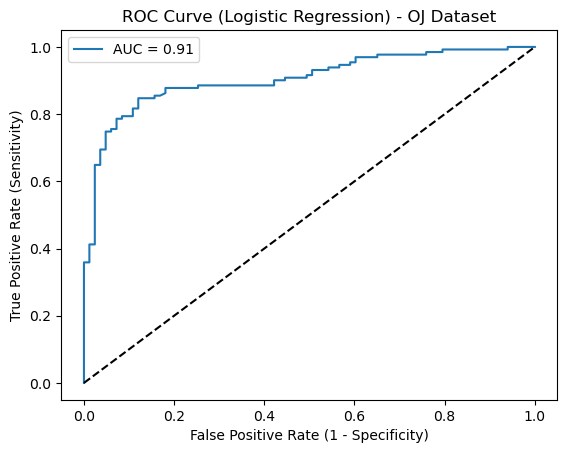

In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# -------------------------
# Evaluate Logistic Regression Performance
# -------------------------

# True values
y_true = y_test.copy()

# Predicted probabilities for class 1 (CH)
y_pred_prob = log_reg.predict_proba(X_test)[:, 1]

# Predicted labels: classify as CH (1) if prob >= 0.5
y_pred = (y_pred_prob >= 0.5).astype(int)

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
print("Confusion Matrix:")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

# Sensitivity (Recall for CH = 1)
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
print("Sensitivity (CH correctly predicted):", sensitivity)

# Specificity (Recall for MM = 0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
print("Specificity (MM correctly predicted):", specificity)

# AUC (Area Under the ROC Curve)
auc = roc_auc_score(y_true, y_pred_prob)
print("AUC:", auc)

# -------------------------
# 6) Plot ROC Curve
# -------------------------
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve (Logistic Regression) - OJ Dataset")
plt.legend()
plt.show()

<div class="exercise"><b>Exercise 3: Understanding the Logistic Regression Evaluation Output</b></div>

In the markdown cell below, answer the following multiple choice questions—no explanations are necessary.  

1. According to the confusion matrix, how many **true positives (TP)** were there?  
   - A) 73  
   - B) 10  
   - C) 20  
   - D) 111  

---

2. What does the model’s **specificity** of 0.88 indicate?  
   - A) 88% of customers who actually purchased CH were correctly predicted.  
   - B) 88% of customers who actually purchased MM were correctly predicted.  
   - C) 88% of all predictions were correct.  
   - D) The model predicted CH 88% of the time.  

---

3. The model’s **AUC = 0.90** suggests that:  
   - A) The model performs poorly at distinguishing between CH and MM.  
   - B) The model correctly ranks a random CH purchase higher than a random MM purchase about 90% of the time.  
   - C) The model misclassifies 90% of the observations.  
   - D) The model predicts CH whenever the probability is 0.9 or higher.  


### Exercise 3 Solutions

1. **D)** 111 — there were 111 **true positives**, meaning the model correctly predicted CH for 111 customers who actually purchased CH.  
2. **B)** 88% — the **specificity** value (0.88) means that 88% of customers who actually purchased **MM** were correctly predicted as MM.  
3. **B)** 0.90 AUC — this indicates that the model correctly ranks a random CH purchase higher than a random MM purchase about **90% of the time**, showing strong overall discrimination ability.  


<div class="exercise"><b>Exercise 4: Fit a Decision Tree Using Cost-Complexity Pruning</b></div>

In the code cell below, write Python code to fit a **classification decision tree** for predicting `Purchase` (`CH` vs. `MM`) using **cost-complexity pruning with cross-validation**.

Follow these steps carefully:

1. **Define the predictors and target:**
   - Use **all 17 predictors**.  
   - Map the response variable `Purchase` to binary values using  
     `{"MM": 0, "CH": 1}` (the same coding used earlier for logistic regression).

2. **Prepare the data:**
   - Use `pd.get_dummies(..., drop_first=True)` to one-hot encode the categorical predictors (`StoreID`, `Store7`, `STORE`, etc.).  
   - Split the data into training and test sets using `train_test_split()` with:
     - `train_size = 0.8`
     - `random_state = 8`
     - `stratify = y`  
     (This ensures the CH/MM ratio is the same in both sets.)

3. **Grow and prune the tree:**
   - Fit a **large tree** using `DecisionTreeClassifier(random_state=8)`.  
   - Compute the **cost-complexity pruning path** using  
     `big_tree.cost_complexity_pruning_path(X_train, y_train)`.  
   - Perform **5-fold cross-validation** across all candidate `ccp_alpha` values to find the α that minimizes the cross-validated classification error.
     - Use `KFold(n_splits=5, shuffle=True, random_state=42)` for reproducibility.

4. **Fit and evaluate the final pruned tree:**
   - Create and fit the final model named **`final_Classtree`** using the optimal α value.  
   - Compute and print:
     - The **selected α** and corresponding cross-validation error.  
     - The **test accuracy** on the held-out data.  
     - The **confusion matrix**.
     - The **sensitivity** and **specificity**. 
     - The list of **predictors used** in the final tree.  

5. **Visualize the tree:**
   - Use `plot_tree()` with `feature_names`, `class_names=["MM", "CH"]`, and `filled=True` to display the final pruned tree.

If completed correctly, your output should display:
- The selected α and its cross-validation error,  
- The test set accuracy, confusion matrix, sensitivity, specificity, and
- A visualization of the final pruned classification tree, matching the format shown in the **Tree-Based Methods in Scikit-Learn** lab.

>Note: While you can reuse most of the code from the `Tree-Based Methods in Scikit-Learn` lab, you will need to make some small changes in order to compute the Sensitivity and Specificity!

**Here is the output from my solution.** 
<p align="center">
  <img src="hw12Data/tree1.png" alt="Figure 1. Pruned Classification Tree" width="800"/>
</p>


Selected alpha (via 5-fold CV): 0.00316551  |  CV Error: 0.1939
Test Accuracy: 0.8598
Confusion Matrix:
TN=65, FP=18, FN=12, TP=119
Sensitivity (CH correctly predicted): 0.9083969465648855
Specificity (MM correctly predicted): 0.7831325301204819
Features used in final pruned tree: ['LoyalCH', 'SalePriceMM', 'PriceDiff', 'ListPriceDiff', 'SpecialCH_1']


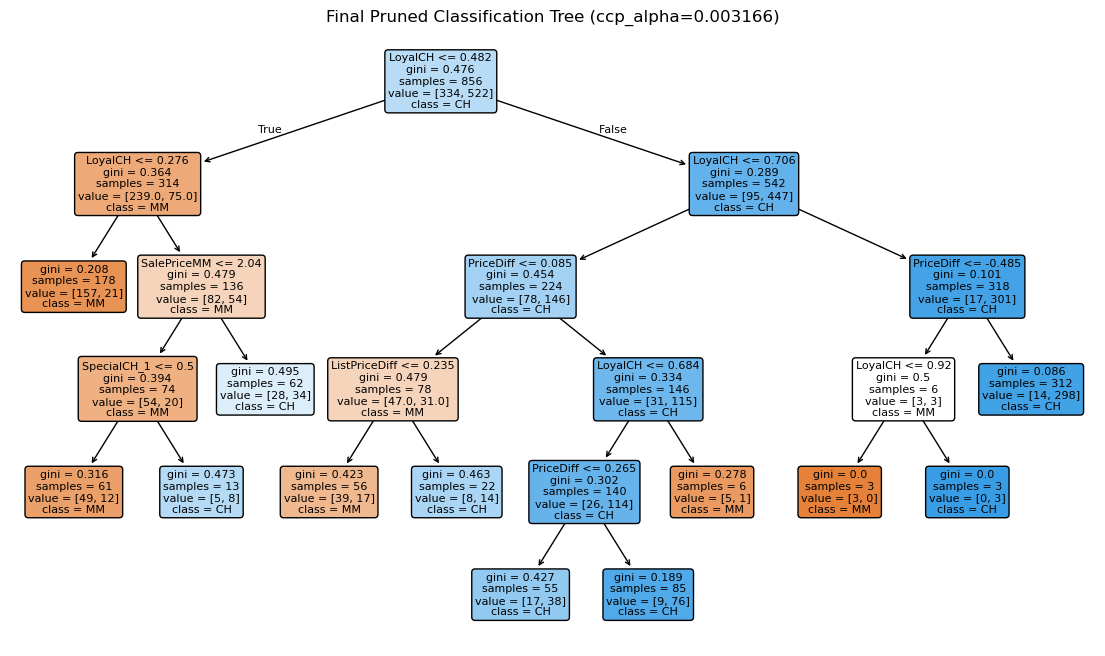

In [9]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

predictors = [
    "WeekofPurchase", "StoreID", "PriceCH", "PriceMM",
    "DiscCH", "DiscMM", "SpecialCH", "SpecialMM",
    "LoyalCH", "SalePriceMM", "SalePriceCH", "PriceDiff",
    "Store7", "PctDiscMM", "PctDiscCH", "ListPriceDiff", "STORE"
]
X_raw = oj_df[predictors].copy()
y = oj_df["Purchase"].map({"MM": 0, "CH": 1}) 
X = pd.get_dummies(X_raw, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=8, stratify=y
)


big_tree = DecisionTreeClassifier(random_state=8)
big_tree.fit(X_train, y_train)
path = big_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

kf = KFold(n_splits=5, shuffle=True, random_state=42) 

cv_results = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=8, ccp_alpha=alpha)
    cv_scores = cross_val_score(
        model, X_train, y_train,
        scoring="accuracy",
        cv=kf
    )
    cv_error = 1.0 - np.mean(cv_scores)
    cv_results.append((alpha, cv_error))

best_alpha, best_cv_err = min(cv_results, key=lambda t: t[1])
print(f"Selected alpha (via 5-fold CV): {best_alpha:.6g}  |  CV Error: {best_cv_err:.4f}")

final_Classtree = DecisionTreeClassifier(random_state=8, ccp_alpha=best_alpha)
final_Classtree.fit(X_train, y_train)

y_pred = final_Classtree.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("Confusion Matrix:")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
print(f"Sensitivity (CH correctly predicted): {sensitivity}")
print(f"Specificity (MM correctly predicted): {specificity}")

used_idx = set(final_Classtree.tree_.feature.tolist()) - {-2}
used_features = [X.columns[i] for i in sorted(list(used_idx))]
print("Features used in final pruned tree:", used_features)

plt.figure(figsize=(14, 8))
plot_tree(
    final_Classtree,
    feature_names=X.columns.tolist(),
    class_names=["MM", "CH"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title(f"Final Pruned Classification Tree (ccp_alpha={best_alpha:.4g})")
plt.show()

<div class="exercise"><b>Exercise 5: Interpreting the Final Pruned Classification Tree</b></div>

In the markdown cell below, answer the following multiple choice questions—no explanations are necessary.

1. The root node of the tree splits on `LoyalCH <= 0.482`.  
   What does this mean in practical terms?  
   - A) Customers with `LoyalCH` greater than 0.482 are **less** loyal to CH.  
   - B) Customers with `LoyalCH` less than or equal to 0.482 are **less** loyal to CH.  
   - C) The split separates customers based on **total spending**.  
   - D) This variable has little impact on the classification.

---

2. Consider the node with `value = [334, 522]` (the root node).  
   What does this tell us about the training data in that node?  
   - A) There were 334 customers who bought CH and 522 who bought MM.  
   - B) There were 334 customers who bought MM and 522 who bought CH.  
   - C) There were 334 customers who did not respond to the offer.  
   - D) There were 334 stores and 522 customers.

---

3. Suppose a new customer has the following attributes:  
   `LoyalCH = 0.3`, `SpecialCH_1 = 0`, and `SalePriceMM = 2.1`.  
   Which branch of the tree would this customer follow and what is the predicted class?  
   - A) Left branch (LoyalCH ≤ 0.482 → LoyalCH ≤ 0.276 → SalePriceMM ≤ 2.04), predicted **MM**.  
   - B) Left branch (LoyalCH ≤ 0.482 → LoyalCH > 0.276 → SalePriceMM > 2.04), predicted **CH**.  
   - C) Right branch (LoyalCH > 0.482), predicted **CH**.  
   - D) Right branch (LoyalCH > 0.706), predicted **MM**.

---

4. Based on the overall structure of the tree, which variable appears to be the **most important predictor** of purchase behavior?  
   - A) `LoyalCH`  
   - B) `PriceDiff`  
   - C) `SpecialCH_1`  
   - D) `ListPriceDiff`


1. A
2. A
3. C
4. A

<div class="exercise"><b>Exercise 6: Export a Text Version of the Decision Tree</b></div>

Recall that `export_text()` from `sklearn.tree` can be used to generate a **text-based representation** of your final decision tree model.

**In the code cell below, write code to print the text-based representation of the tree.**

The partial output from my solution is as follows:

<code>
|--- LoyalCH <= 0.48  
|   |--- LoyalCH <= 0.28  
|   |   |--- class: 0  
|   |--- LoyalCH >  0.28  
|   |   |--- SalePriceMM <= 2.04  
|   |   |   |--- SpecialCH_1 <= 0.50  
|   |   |   |   |--- class: 0  
|   |   |   |--- SpecialCH_1 >  0.50  
|   |   |   |   |--- class: 1  
|   |   |--- SalePriceMM >  2.04  
|   |   |   |--- class: 1  
.
.
.
</code>

In [10]:
from sklearn.tree import export_text

tree_rules = export_text(final_Classtree, feature_names=list(X.columns))
print(tree_rules)

|--- LoyalCH <= 0.48
|   |--- LoyalCH <= 0.28
|   |   |--- class: 0
|   |--- LoyalCH >  0.28
|   |   |--- SalePriceMM <= 2.04
|   |   |   |--- SpecialCH_1 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- SpecialCH_1 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- SalePriceMM >  2.04
|   |   |   |--- class: 1
|--- LoyalCH >  0.48
|   |--- LoyalCH <= 0.71
|   |   |--- PriceDiff <= 0.09
|   |   |   |--- ListPriceDiff <= 0.23
|   |   |   |   |--- class: 0
|   |   |   |--- ListPriceDiff >  0.23
|   |   |   |   |--- class: 1
|   |   |--- PriceDiff >  0.09
|   |   |   |--- LoyalCH <= 0.68
|   |   |   |   |--- PriceDiff <= 0.27
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- PriceDiff >  0.27
|   |   |   |   |   |--- class: 1
|   |   |   |--- LoyalCH >  0.68
|   |   |   |   |--- class: 0
|   |--- LoyalCH >  0.71
|   |   |--- PriceDiff <= -0.48
|   |   |   |--- LoyalCH <= 0.92
|   |   |   |   |--- class: 0
|   |   |   |--- LoyalCH >  0.92
|   |   |   |   |--- class: 1
|   |   |-

<div class="exercise"><b>Exercise 7: Predict the Purchase Decision for a New Customer</b></div>

In this exercise, you’ll use your **final pruned classification tree** to predict the purchase decision for a **new customer** — rather than tracing the tree visually.

Your goal is to:
1. Create a new `DataFrame` containing the customer’s predictor values.  
2. Use `.predict()` to obtain the predicted **class label**.  
3. Use `.predict_proba()` to obtain the **predicted probability** that the customer will purchase **Tropicana (CH)**.

Use the following predictor values for the new customer:

| Predictor | Value |
|------------|-------|
| `LoyalCH` | 0.65 |
| `SalePriceMM` | 1.95 |
| `PriceDiff` | 0.10 |
| `ListPriceDiff` | 0.20 |
| `SpecialCH_1` | 0 |

Be sure to use `.reindex(columns=X.columns, fill_value=0)` to align your new observation with the training data’s column structure.

**In the code cell below, write code to create the new customer, make the prediction, and print both the predicted class and the probability.**

Expected output:
<code>
Predicted class: Tropicana (CH) | Probability(CH) = 0.691
</code>

In [11]:
new_customer = pd.DataFrame([{
    "LoyalCH": 0.65,
    "SalePriceMM": 1.95,
    "PriceDiff": 0.10,
    "ListPriceDiff": 0.20,
    "SpecialCH_1": 0
}]).reindex(columns=X.columns, fill_value=0)

pred_class = final_Classtree.predict(new_customer)[0]
pred_proba_CH = final_Classtree.predict_proba(new_customer)[0, 1]

print(f"Predicted class: {'Tropicana (CH)' if pred_class == 1 else 'Minute Maid (MM)'} "
      f"| Probability(CH) = {pred_proba_CH:.3f}")

Predicted class: Tropicana (CH) | Probability(CH) = 0.691


<div class="exercise"><b>Exercise 8: Fit a Random Forest Classifier</b></div>

In this exercise, you’ll train a **Random Forest classifier** to predict which brand of orange juice (`Purchase`: CH or MM) a customer will buy.  

**Instructions**
Write code to:
1. Use **all available predictors** in the dataset. 
2. **One-hot encode** categorical variables 
3. Split the data into **training (80%)** and **test (20%)** sets, using `stratify=y` and `random_state=8` to preserve class balance.  
4. Fit a **RandomForestClassifier** with:
   - **500 trees** (`n_estimators=500`)  
   - **max_features = √p**, where `p` is the number of predictors, to decorrelate trees  
   - `random_state=8` for reproducibility  
5. After fitting, compute and print:
   - The **number of predictors** (`p`) and chosen `max_features` (`m`)  
   - The **test accuracy**  
   - The **confusion matrix**
   - The **Sensitivity** and the **Specificity**
   - The **top 10 most important predictors** (sorted by importance)

>Note: While you can reuse most of the code from the `Tree-Based Methods in Scikit-Learn` lab, you will need to make some small changes in order to compute the Sensitivity and Specificity!
>
The output from my solution is as follows:
```python
Number of predictors (p): 23, max_features (m): 4
Random Forest Test Accuracy: 0.8037
Confusion Matrix:
TN=63, FP=20, FN=22, TP=109
Sensitivity (CH correctly predicted): 0.8320610687022901
Specificity (MM correctly predicted): 0.7590361445783133

Top features by importance:
                importance
LoyalCH           0.562426
WeekofPurchase    0.114378
PriceDiff         0.046755
SalePriceMM       0.030603
ListPriceDiff     0.026434
SalePriceCH       0.019443
PriceMM           0.018018
PriceCH           0.016275
Store7_Yes        0.015361
StoreID_7         0.015311


In [12]:
from sklearn.ensemble import RandomForestClassifier

predictors = [
    "WeekofPurchase", "StoreID", "PriceCH", "PriceMM",
    "DiscCH", "DiscMM", "SpecialCH", "SpecialMM",
    "LoyalCH", "SalePriceMM", "SalePriceCH", "PriceDiff",
    "Store7", "PctDiscMM", "PctDiscCH", "ListPriceDiff", "STORE"
]
X_raw = oj_df[predictors].copy()
y = oj_df["Purchase"].map({"MM": 0, "CH": 1}) 

X = pd.get_dummies(X_raw, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=8, stratify=y
)

p = X_train.shape[1]
m = int(np.sqrt(p))
print(f"Number of predictors (p): {p}, max_features (m): {m}")

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_features=m,
    random_state=8
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f"\nRandom Forest Test Accuracy: {test_acc:.4f}")
print("Confusion Matrix:")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Sensitivity (CH correctly predicted): {sensitivity}")
print(f"Specificity (MM correctly predicted): {specificity}")

importances = pd.DataFrame(
    {'importance': rf_model.feature_importances_},
    index=X.columns
).sort_values(by='importance', ascending=False)

print("\nTop features by importance (top 10):")
print(importances.head(10))

Number of predictors (p): 23, max_features (m): 4

Random Forest Test Accuracy: 0.8037
Confusion Matrix:
TN=63, FP=20, FN=22, TP=109
Sensitivity (CH correctly predicted): 0.8320610687022901
Specificity (MM correctly predicted): 0.7590361445783133

Top features by importance (top 10):
                importance
LoyalCH           0.562426
WeekofPurchase    0.114378
PriceDiff         0.046755
SalePriceMM       0.030603
ListPriceDiff     0.026434
SalePriceCH       0.019443
PriceMM           0.018018
PriceCH           0.016275
Store7_Yes        0.015361
StoreID_7         0.015311


<div class="exercise"><b>Exercise 9: Understanding the Random Forest Output</b></div>

In the markdown cell below, answer the following multiple choice questions—no explanations are necessary.

1. Based on the confusion matrix, how many customers who actually purchased **CH** were **incorrectly classified** as MM?  
 - A) 20  
 - B) 22  
 - C) 63  
 - D) 109  

---

2. Which variable appears to be the **most important predictor** of purchase decision according to the random forest?  
 - A) `WeekofPurchase`  
 - B) `PriceDiff`  
 - C) `LoyalCH`  
 - D) `SalePriceMM`  

---

3. What does `max_features = 4` mean in this random forest model?  
 - A) Only 4 trees were grown in total.  
 - B) Each tree uses only 4 randomly selected predictors at each split.  
 - C) The model was limited to using 4 predictors overall.  
 - D) The top 4 features were used to make final predictions.  

---

4. How should we interpret the test accuracy of **0.8037**?  
 - A) The model correctly predicted about **80%** of purchases in the test data.  
 - B) The model correctly predicted **80%** of CH purchases only.  
 - C) The model misclassified **80%** of the test data.  
 - D) The model’s predictions are random and unreliable. 


1 B 
2 C
3 B
4 A

<div class="exercise"><b>Exercise 10: Apply Gradient Boosting to the OJ Dataset</b></div>

In this exercise, you’ll fit a **Gradient Boosting Classifier** to predict which brand of orange juice (`CH` or `MM`) a customer will purchase.  
Gradient boosting is another ensemble method that builds trees **sequentially**, where each new tree focuses on correcting the errors made by the previous ones.

You’ll reuse the **training and test sets** (`X_train`, `X_test`, `y_train`, `y_test`) from the **Random Forest** exercise to ensure a fair comparison.

### Instructions
1. Use the `GradientBoostingClassifier()` from `sklearn.ensemble` to fit a boosting model with the following parameters:  
   - `n_estimators=500` — number of boosting stages (trees).  
   - `learning_rate=0.01` — controls how much each tree contributes (a smaller value = slower but more stable learning).  
   - `max_depth=3` — maximum depth of individual trees.  
   - `random_state=8` — ensures reproducibility.  

2. After fitting the model:
   - Make predictions on the **test set**.  
   - Compute and print:
     - The **test accuracy**  
     - The **confusion matrix**
     - The **Sensitivity** and **Specificity**
     - The **top 10 most important features** ranked by their relative importance.

>Note: While you can reuse most of the code from the `Tree-Based Methods in Scikit-Learn` lab, you will need to make some small changes in order to compute the Sensitivity and Specificity!
>
The output from my solution is as follows:
```python
Gradient Boosting Test Accuracy: 0.8551
Confusion Matrix:
TN=70, FP=13, FN=18, TP=113
Sensitivity (CH correctly predicted): 0.8625954198473282
Specificity (MM correctly predicted): 0.8433734939759037

Top features by importance:
                importance
LoyalCH           0.772777
PriceDiff         0.097981
ListPriceDiff     0.028317
SalePriceMM       0.020974
WeekofPurchase    0.016741
SpecialCH_1       0.014934
SalePriceCH       0.006571
PctDiscCH         0.005358
STORE_4           0.005151
PctDiscMM         0.005059

In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=500,      
    learning_rate=0.01,    
    max_depth=3,          
    random_state=8
)

gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f"Gradient Boosting Test Accuracy: {test_acc:.4f}")
print("Confusion Matrix:")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Sensitivity (CH correctly predicted): {sensitivity}")
print(f"Specificity (MM correctly predicted): {specificity}")

importances = pd.DataFrame(
    {"importance": gb_model.feature_importances_},
    index=X.columns
).sort_values(by="importance", ascending=False)

print("\nTop features by importance:")
print(importances.head(10))

Gradient Boosting Test Accuracy: 0.8551
Confusion Matrix:
TN=70, FP=13, FN=18, TP=113
Sensitivity (CH correctly predicted): 0.8625954198473282
Specificity (MM correctly predicted): 0.8433734939759037

Top features by importance:
                importance
LoyalCH           0.772689
PriceDiff         0.098044
ListPriceDiff     0.028317
SalePriceMM       0.020691
WeekofPurchase    0.016823
SpecialCH_1       0.014874
SalePriceCH       0.006558
PctDiscCH         0.005358
PctDiscMM         0.005339
StoreID_4         0.005217


<div class="exercise"><b>Exercise 11: Understanding the Gradient Boosting Output</b></div>

Answer the following multiple choice questions based on the Gradient Boosting model results below — no explanations are necessary.

---

1. In gradient boosting, what does the **learning rate = 0.01** control?  
 - A) The maximum number of features considered at each split.  
 - B) The number of trees in the ensemble.  
 - C) How much each successive tree contributes to correcting previous errors.  
 - D) The size of the training set used for each tree.  

---

2. The top feature `LoyalCH` has an importance value of **0.77**, while the next highest is only **0.10**. What does this suggest about the model?  
 - A) The model heavily relies on **customer loyalty** to make predictions.  
 - B) The model overfits to price variables and ignores loyalty.  
 - C) The loyalty variable is weak and should be dropped.  
 - D) All features contribute equally to the predictions.  

---

3. Compared to the decision tree and random forest models, what advantage does **gradient boosting** typically provide?  
 - A) It trains all trees independently on random data subsets.  
 - B) It builds trees **sequentially**, each one improving on the mistakes of the previous model.  
 - C) It combines many small trees by averaging their predictions, not summing them.  
 - D) It automatically prunes trees after every split to reduce overfitting.  









1 C 
2 A
3 B

<div class="exercise"><b>Exercise 12: Comparing Model Performance Across Methods</b></div>

Below are the results from four different models predicting which brand of orange juice (`CH` or `MM`) customers purchase.  

### Summary of Results

| Model | Test Accuracy | Sensitivity (CH) | Specificity (MM) |
|:------|:--------------:|:----------------:|:----------------:|
| **Logistic Regression** | **0.86** | 0.85 | 0.88 |
| **Pruned Decision Tree** | **0.86** | **0.91** | **0.78** |
| **Random Forest** | **0.80** | **0.83** | **0.76** |
| **Gradient Boosting** | **0.86** | **0.86** | **0.84** |

---

### Multiple Choice Questions

1. Which model achieved the **most balanced** performance between sensitivity and specificity?  
   - A) Logistic Regression  
   - B) Pruned Decision Tree  
   - C) Random Forest  
   - D) Gradient Boosting  

---

2. What can we infer from the **decision tree’s high sensitivity (0.91)** and **lower specificity (0.78)**?  
   - A) It is more likely to predict **CH** when uncertain.  
   - B) It is more likely to predict **MM** when uncertain.  
   - C) It performs equally well on both classes.  
   - D) It ignores CH cases completely.  

---

3. Which statement best summarizes the comparison among all four models?  
   - A) Logistic Regression and Gradient Boosting achieved similar, balanced performance.  
   - B) Random Forest was the most accurate model.  
   - C) The Pruned Tree and Random Forest both struggled to identify CH purchases.  
   - D) Boosting showed the weakest ability to generalize to new data.  


1 A
2 A
3 A